In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from IPython.display import Image

FIRST WE ARE GOING TO CREATE A SIMPLER CONDITIONAL WORKFLOW AND THEN WE WILL MOVE FORWARD TO COMPLEX THINGS

In [16]:
# quadratic formula solver 
class QState(TypedDict):
    a: float
    b: float
    c: float

    equation: Annotated[str, Field(description="The quadratic equation in the form ax^2 + bx + c = 0")]
    discriminant: Annotated[float, Field(description="The discriminant of the quadratic equation, calculated as b^2 - 4ac")]
    result: str

In [17]:
def show_equation(state: QState) -> QState:
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {"equation": equation}

def calculate_discriminant(state: QState) -> QState:
    discriminant = state['b']**2 - 4*state['a']*state['c']
    return {"discriminant": round(float(discriminant),2)}

def real_roots(state: QState) -> QState:
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    return {"result": f"Two real roots: {round(root1,2)} and {round(root2,2)}"}

def same_roots(state: QState) -> QState:
    root = -state['b'] / (2*state['a'])
    return {"result": f"One real root: {round(root,2)}"}

def complex_roots(state: QState) -> QState:
    result = "No real roots, but two complex roots."
    return {"result": result}

def check_condition(state: QState) -> Literal["real_roots", "same_roots", "complex_roots"]:
    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "same_roots"
    else:
        return "complex_roots"

In [19]:
graph = StateGraph(QState)

graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("same_roots", same_roots)
graph.add_node("complex_roots", complex_roots)


graph.add_conditional_edges("calculate_discriminant", check_condition)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")
graph.add_edge("real_roots", END)
graph.add_edge("same_roots", END)
graph.add_edge("complex_roots", END)


workflow = graph.compile()

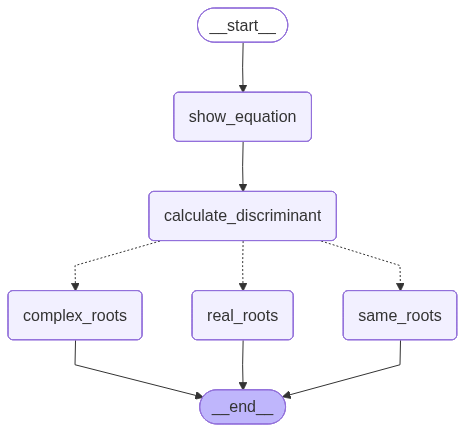

In [20]:
Image(workflow.get_graph().draw_mermaid_png())

In [22]:
query = {
    "a": 1,
    "b": -3,
    "c": 2
}
result = workflow.invoke(query)
result

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1.0,
 'result': 'Two real roots: 2.0 and 1.0'}